# SED Spectral Model

This notebook demonstrates how to perform a binned spectral energy distribution (SED) fit with COSIPy. The SED is modeled with independent flux normalizations in each selected true-energy bin, allowing the spectrum to be reconstructed without assuming a global spectral shape. The example also shows how to identify poorly constrained bins, refit after freezing boundary-dominated parameters, and calculate profile-likelihood upper limits where appropriate.This notebook demonstrates how to perform a binned spectral energy distribution (SED) fit with COSIPy. The SED is modeled as a piecewise power law in true energy, with an independent differential flux normalization in each selected energy bin. Within each bin, the spectrum is defined as


$$\frac{dN}{dE} = K_i \left(\frac{E}{E_{\mathrm{piv},i}}\right)^{\alpha},$$


where (K_i) is the fitted normalization for bin (i), (E_{\mathrm{piv},i}) is the geometric-center energy of the bin, and (\alpha) is a fixed local power-law index shared across the bins. This approach reconstructs the spectrum bin by bin without imposing a single global spectral shape.

The example shows how to construct the generalized `BinnedSED` model directly from the COSI response, perform the likelihood fit, identify bins whose fitted normalizations are dominated by the lower boundary at zero, refit after freezing those bins, and calculate profile-likelihood upper limits where appropriate. The resulting flux points and upper limits can then be used to construct the reconstructed true-energy SED.


### Imports:

In [1]:
import logging
import sys
import os

logger = logging.getLogger('cosipy')
logger.setLevel(logging.INFO)
logger.addHandler(logging.StreamHandler(sys.stdout))

os.environ["OMP_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["NUMEXPR_NUM_THREADS"] = "1"

In [2]:
from cosipy import BinnedData
from cosipy.statistics import PoissonLikelihood
from cosipy.background_estimation import FreeNormBinnedBackground
from cosipy.interfaces import ThreeMLPluginInterface
from cosipy.response import BinnedThreeMLModelFolding, BinnedInstrumentResponse, BinnedThreeMLExtendedSourceResponse
from cosipy.data_io import EmCDSBinnedData
from cosipy.spacecraftfile import SpacecraftHistory
from cosipy.response.FullDetectorResponse import FullDetectorResponse
from cosipy.response.ExtendedSourceResponse import ExtendedSourceResponse
from cosipy.threeml.custom_functions import GalpropHealpixModel
from cosipy.util import fetch_wasabi_file
from cosipy.threeml import freeze_binned_sed_bins
from threeML import PointSource, Model, JointLikelihood, DataList, update_logging_level
from threeML.analysis_results import *
from astromodels import *
from astromodels.functions import GalPropTemplate_3D
import numpy as np
import matplotlib.pyplot as plt

15:07:46 WARNING   The naima package is not available. Models that depend on it will not be         ]8;id=15784955;file:///project/ckarwin/astro/chris/my_envs/cosipy_dev/lib/python3.12/site-packages/astromodels/functions/functions_1D/functions.py\functions.py]8;;\:]8;id=15784956;file:///project/ckarwin/astro/chris/my_envs/cosipy_dev/lib/python3.12/site-packages/astromodels/functions/functions_1D/functions.py#43\43]8;;\
                  available                                                                                        

         WARNING   The GSL library or the pygsl wrapper cannot be loaded. Models that depend on it  ]8;id=15784962;file:///project/ckarwin/astro/chris/my_envs/cosipy_dev/lib/python3.12/site-packages/astromodels/functions/functions_1D/functions.py\functions.py]8;;\:]8;id=15784963;file:///project/ckarwin/astro/chris/my_envs/cosipy_dev/lib/python3.12/site-packages/astromodels/functions/functions_1D/functions.py#65\65]8;;\
                  will not be available.                                                                           

15:07:48 WARNING   The ebltable package is not available. Models that depend on it will not be     ]8;id=15784970;file:///project/ckarwin/astro/chris/my_envs/cosipy_dev/lib/python3.12/site-packages/astromodels/functions/functions_1D/absorption.py\absorption.py]8;;\:]8;id=15784971;file:///project/ckarwin/astro/chris/my_envs/cosipy_dev/lib/python3.12/site-packages/astromodels/functions/functions_1D/absorption.py#33\33]8;;\
                  available                                                                                        

15:07:49 INFO      Starting 3ML!                                                                     ]8;id=15784978;file:///project/ckarwin/astro/chris/my_envs/cosipy_dev/lib/python3.12/site-packages/threeML/__init__.py\__init__.py]8;;\:]8;id=15784979;file:///project/ckarwin/astro/chris/my_envs/cosipy_dev/lib/python3.12/site-packages/threeML/__init__.py#44\44]8;;\

         WARNING   WARNINGs here are NOT errors                                                      ]8;id=15784985;file:///project/ckarwin/astro/chris/my_envs/cosipy_dev/lib/python3.12/site-packages/threeML/__init__.py\__init__.py]8;;\:]8;id=15784986;file:///project/ckarwin/astro/chris/my_envs/cosipy_dev/lib/python3.12/site-packages/threeML/__init__.py#45\45]8;;\

...

15:07:50 WARNING   ROOT minimizer not available                                                ]8;id=15785014;file:///project/ckarwin/astro/chris/my_envs/cosipy_dev/lib/python3.12/site-packages/threeML/minimizer/minimization.py\minimization.py]8;;\:]8;id=15785015;file:///project/ckarwin/astro/chris/my_envs/cosipy_dev/lib/python3.12/site-packages/threeML/minimizer/minimization.py#1208\1208]8;;\

         WARNING   Multinest minimizer not available                                           ]8;id=15785021;file:///project/ckarwin/astro/chris/my_envs/cosipy_dev/lib/python3.12/site-packages/threeML/minimizer/minimization.py\minimization.py]8;;\:]8;id=15785022;file:///project/ckarwin/astro/chris/my_envs/cosipy_dev/lib/python3.12/site-packages/threeML/minimizer/minimization.py#1218\1218]8;;\

         WARNING   PyGMO is not available                                                      ]8;id=15785028;file:///project/ckarwin/astro/chris/my_envs/cosipy_dev/lib/python3.12/site-packages/threeML/minimizer/minimization.py\minimization.py]8;;\:]8;id=15785029;file:///project/ckarwin/astro/chris/my_envs/cosipy_dev/lib/python3.12/site-packages/threeML/minimizer/minimization.py#1228\1228]8;;\

15:07:51 WARNING   Could not import plugin FermiLATLike.py. Do you have the relative instrument     ]8;id=15785035;file:///project/ckarwin/astro/chris/my_envs/cosipy_dev/lib/python3.12/site-packages/threeML/__init__.py\__init__.py]8;;\:]8;id=15785036;file:///project/ckarwin/astro/chris/my_envs/cosipy_dev/lib/python3.12/site-packages/threeML/__init__.py#126\126]8;;\
                  software installed and configured?                                                               

15:07:53 WARNING   No fermitools installed                                              ]8;id=15785043;file:///project/ckarwin/astro/chris/my_envs/cosipy_dev/lib/python3.12/site-packages/threeML/utils/data_builders/fermi/lat_transient_builder.py\lat_transient_builder.py]8;;\:]8;id=15785044;file:///project/ckarwin/astro/chris/my_envs/cosipy_dev/lib/python3.12/site-packages/threeML/utils/data_builders/fermi/lat_transient_builder.py#44\44]8;;\

## Download files:
Run this to get the needed files

In [9]:
#fetch_wasabi_file("COSI-SMEX/DC4/Data/Orientation/DC4_final_530km_3_month_with_slew_15sbins_GalacticEarth_SAA.fits", checksum = 'ca94ff1d7a73c1f41479aaf598807673')
#fetch_wasabi_file("COSI-SMEX/DC3/Data/Responses/extended_source_response/extended_source_response_continuum_merged.h5.gz", unzip=True, checksum = '92ed7e22b1dafce6b57611d5cdb6cf70')
#fetch_wasabi_file("COSI-SMEX/DC4/Data/Backgrounds/Total_DC4_BG_3months_unbinned_data_filtered_with_SAAcut_withSAAbck.fits.gz", checksum = '73c8b23e43684da3b35c25499254202b')
#fetch_wasabi_file("COSI-SMEX/DC4/Data/Sources/positron_annihilation_in_flight_3months_unbinned_data_filtered_with_SAAcut.fits.gz", checksum = '5d9d2ca1433e571dfb2f06cb8236fd59')

## Inputs: 

In [3]:
data_path = Path(".")

ori_file = data_path / "DC4_final_530km_3_month_with_slew_15sbins_GalacticEarth_SAA.fits"
psr_file = data_path / "extended_source_response_continuum_merged.h5"

# Load BG:
bg_file = data_path / "Total_DC4_BG_3months_unbinned_data_filtered_with_SAAcut_withSAAbck.fits.gz"
total_bg = BinnedData("galdiff.yaml")
if os.path.exists('total_BG_binned_data.hdf5') == False:
    total_bg.get_binned_data(unbinned_data = bg_file, output_name="total_BG_binned_data")
else:
    total_bg.load_binned_data_from_hdf5(binned_data = "total_BG_binned_data.hdf5") # after binning 

# Load in-flight binned data: 
inflight_file = data_path / "positron_annihilation_in_flight_3months_unbinned_data_filtered_with_SAAcut.fits.gz"
inflight_sim = BinnedData("galdiff.yaml")
if os.path.exists('inflight_binned_data.hdf5') == False:
    inflight_sim.get_binned_data(unbinned_data = inflight_file, output_name="inflight_binned_data") 
else:
    inflight_sim.load_binned_data_from_hdf5(binned_data= "inflight_binned_data.hdf5") # after binning
 
mock_dataset = total_bg.binned_data.project('Em', 'Phi', 'PsiChi') + inflight_sim.binned_data.project('Em', 'Phi', 'PsiChi')

## Define in-flight model:

In [4]:
# Custom SED spectral model

from cosipy.threeml import (
    BinnedSED,
)

# ------------------------------------------------------------------
# Open response
# ------------------------------------------------------------------

dr = ExtendedSourceResponse.open(psr_file)


# ------------------------------------------------------------------
# SED spectral model
# ------------------------------------------------------------------

ei_bins = range(0, 10)

spec_inflight = BinnedSED.from_response(
    dr,
    ei_bin_indices=ei_bins,
    initial_fluxes=[1e-7] * len(ei_bins),
)


# ------------------------------------------------------------------
# Spatial morphology
# ------------------------------------------------------------------

morphology = Gaussian_on_sphere(
    lon0=359.8,
    lat0=-1.4,
    sigma=3.3,
)

morphology.lon0.free = False
morphology.lat0.free = False
morphology.sigma.free = False


# ------------------------------------------------------------------
# Extended source
#
# Do not assign units manually. ExtendedSource / astromodels calls
# set_units internally.
# ------------------------------------------------------------------

inflight_src = ExtendedSource(
    "in_flight",
    spectral_shape=spec_inflight,
    spatial_shape=morphology,
)


# Display the complete source model
inflight_src.display()

* in_flight (extended source):
    * shape:
      * lon0:
        * value: 359.8
        * desc: Longitude of the center of the source
        * min_value: 0.0
        * max_value: 360.0
        * unit: deg
        * is_normalization: false
      * lat0:
        * value: -1.4
        * desc: Latitude of the center of the source
        * min_value: -90.0
        * max_value: 90.0
        * unit: deg
        * is_normalization: false
      * sigma:
        * value: 3.3
        * desc: Standard deviation of the Gaussian distribution
        * min_value: 0.0
        * max_value: 20.0
        * unit: deg
        * is_normalization: false
    * spectrum:
      * main:
        * BinnedSED_10:
          * K0:
            * value: 1.0e-07
            * desc: Differential normalization in true-energy bin 0
            * min_value: 0.0
            * max_value: 0.01
            * unit: keV-1 s-1 cm-2
            * is_normalization: true
          * K1:
            * value: 1.0e-07
            * desc: Differential normalization in true-energy bin 1
            * min_value: 0.0
            * max_value: 0.01
            * unit: keV-1 s-1 cm-2
            * is_normalization: false
          * K2:
            * value: 1.0e-07
            * desc: Differential normalization in true-energy bin 2
            * min_value: 0.0
            * max_value: 0.01
            * unit: keV-1 s-1 cm-2
            * is_normalization: false
          * K3:
            * value: 1.0e-07
            * desc: Differential normalization in true-energy bin 3
            * min_value: 0.0
            * max_value: 0.01
            * unit: keV-1 s-1 cm-2
            * is_normalization: false
          * K4:
            * value: 1.0e-07
            * desc: Differential normalization in true-energy bin 4
            * min_value: 0.0
            * max_value: 0.01
            * unit: keV-1 s-1 cm-2
            * is_normalization: false
          * K5:
            * value: 1.0e-07
            * desc: Differential normalization in true-energy bin 5
            * min_value: 0.0
            * max_value: 0.01
            * unit: keV-1 s-1 cm-2
            * is_normalization: false
          * K6:
            * value: 1.0e-07
            * desc: Differential normalization in true-energy bin 6
            * min_value: 0.0
            * max_value: 0.01
            * unit: keV-1 s-1 cm-2
            * is_normalization: false
          * K7:
            * value: 1.0e-07
            * desc: Differential normalization in true-energy bin 7
            * min_value: 0.0
            * max_value: 0.01
            * unit: keV-1 s-1 cm-2
            * is_normalization: false
          * K8:
            * value: 1.0e-07
            * desc: Differential normalization in true-energy bin 8
            * min_value: 0.0
            * max_value: 0.01
            * unit: keV-1 s-1 cm-2
            * is_normalization: false
          * K9:
            * value: 1.0e-07
            * desc: Differential normalization in true-energy bin 9
            * min_value: 0.0
            * max_value: 0.01
            * unit: keV-1 s-1 cm-2
            * is_normalization: false
          * E0:
            * value: 100.0
            * desc: Lower edge of SED bin 0
            * min_value: null
            * max_value: null
            * unit: keV
            * is_normalization: false
          * E1:
            * value: 158.489
            * desc: Edge between SED bins 0 and 1
            * min_value: null
            * max_value: null
            * unit: keV
            * is_normalization: false
          * E2:
            * value: 251.189
            * desc: Edge between SED bins 1 and 2
            * min_value: null
            * max_value: null
            * unit: keV
            * is_normalization: false
          * E3:
            * value: 398.107
            * desc: Edge between SED bins 2 and 3
            * min_value: null
            * max_value: null
            * unit: keV
            * is_normalization: f

### Plot In-Flight Spectral Model:

energy[0] = 100.0
SED range  = 100.0 10000.0
flux[0] = 1.58489e-07
max flux = 1.58489e-07
nonzero points = 500


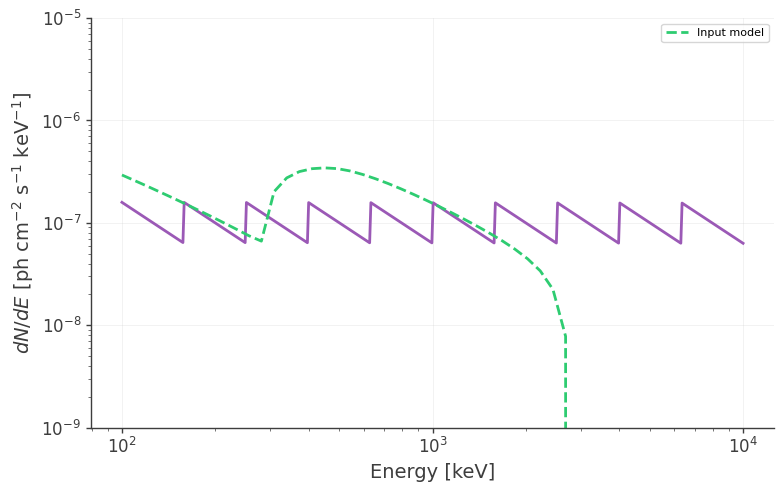

In [5]:
%matplotlib inline

# Energy grid in keV
energy = np.geomspace(100.0, 1.0e4, 500)

# Evaluate the astromodels spectral function
flux = spec_inflight(energy)


print("energy[0] =", energy[0])
print("SED range  =", spec_inflight.bin_edges[0], spec_inflight.bin_edges[-1])

flux = spec_inflight(energy)

print("flux[0] =", flux[0])
print("max flux =", np.max(flux))
print("nonzero points =", np.count_nonzero(flux))

# Convert astropy quantities to arrays if necessary
energy_plot = getattr(energy, "value", energy)
flux_plot = getattr(flux, "value", flux)

fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(
    energy_plot,
    flux_plot,
    linewidth=2,
)

df = pd.read_csv(
    "Positrons_In_Flight_Annihilation_spec.dat",
    sep=r"\s+",
    skiprows=5,
    names=["dummy", "energy", "flux"],
)

ax.plot(
    df["energy"],
   df["flux"],
    label="Input model",
    linestyle="--",
)

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("Energy [keV]")
ax.set_ylabel(
    r"$dN/dE$ [ph cm$^{-2}$ s$^{-1}$ keV$^{-1}$]"
)
ax.grid(alpha=0.3)
ax.legend()
fig.tight_layout()

plt.ylim(1e-9,1e-5)
plt.show()

Define model

In [6]:
model = Model(inflight_src)
model.display()

Model summary:
==============

                  N
Point sources     0
Extended sources  1
Particle sources  0

Free parameters (10):
--------------------

                                        value min_value max_value  \
in_flight.spectrum.main.BinnedSED_10.K0   0.0       0.0      0.01   
in_flight.spectrum.main.BinnedSED_10.K1   0.0       0.0      0.01   
in_flight.spectrum.main.BinnedSED_10.K2   0.0       0.0      0.01   
in_flight.spectrum.main.BinnedSED_10.K3   0.0       0.0      0.01   
in_flight.spectrum.main.BinnedSED_10.K4   0.0       0.0      0.01   
in_flight.spectrum.main.BinnedSED_10.K5   0.0       0.0      0.01   
in_flight.spectrum.main.BinnedSED_10.K6   0.0       0.0      0.01   
in_flight.spectrum.main.BinnedSED_10.K7   0.0       0.0      0.01   
in_flight.spectrum.main.BinnedSED_10.K8   0.0       0.0      0.01   
in_flight.spectrum.main.BinnedSED_10.K9   0.0       0.0      0.01   

                                                   unit  
in_flight.spectrum.main.BinnedSED_10.K0  keV-1 s-1 cm-2  
in_flight.spectrum.main.BinnedSED_10.K1  keV-1 s-1 cm-2  
in_flight.spectrum.main.BinnedSED_10.K2  keV-1 s-1 cm-2  
in_flight.spectrum.main.BinnedSED_10.K3  keV-1 s-1 cm-2  
in_flight.spectrum.main.BinnedSED_10.K4  keV-1 s-1 cm-2  
in_flight.spectrum.main.BinnedSED_10.K5  keV-1 s-1 cm-2  
in_flight.spectrum.main.BinnedSED_10.K6  keV-1 s-1 cm-2  
in_flight.spectrum.main.BinnedSED_10.K7  keV-1 s-1 cm-2  
in_flight.spectrum.main.BinnedSED_10.K8  keV-1 s-1 cm-2  
in_flight.spectrum.main.BinnedSED_10.K9  keV-1 s-1 cm-2  

Fixed parameters (15):
(abridged. Use complete=True to see all fixed parameters)


Properties (0):
--------------------

(none)


Linked parameters (0):
----------------------

(none)

Independent variables:
----------------------

(none)

Linked functions (0):
----------------------

(none)

## Setup and perform fit
Setup background parameter, extended source , orientation file and the LH fit

In [7]:
#open the orientation file
sc_orientation = SpacecraftHistory.open(ori_file)

#open the extended source response
dr = ExtendedSourceResponse.open(psr_file)


bkg_dist = {"total_bg":total_bg.binned_data.project('Em', 'Phi', 'PsiChi')}

# Workaround to avoid inf values. Out bkg should be smooth, but currently it's not.
# Reproduces results before refactoring. It's not _exactly_ the same, since this fudge value was 1e-12, and
# it was added to the expectation, not the normalized bkg
for bckfile in bkg_dist.keys() :
    bkg_dist[bckfile] += sys.float_info.min

    input_bg_norms = {}

# print input normalization value:
print("input rates:")
for label, hist in bkg_dist.items():
    input_counts = np.sum(hist)
    input_rate = input_counts / sc_orientation.cumulative_livetime().to_value(u.s)

    input_bg_norms[label] = input_rate

    print(f"{label}: {input_rate:.6g} Hz ")
    

data = EmCDSBinnedData(mock_dataset)
    
bkg = FreeNormBinnedBackground(bkg_dist,
                                   sc_history=sc_orientation,
                                   copy = False)

# Currently using the same NnuLambda, Ei and Pol axes as the underlying FullDetectorResponse,
# matching the behavior of v0.3. This is all the current BinnedInstrumentResponse can do.
# In principle, this can be decoupled, and a BinnedInstrumentResponseInterface implementation
# can provide the response for an arbitrary directions, Ei and Pol values.
    

esr = BinnedThreeMLExtendedSourceResponse(data = data,
                                          precomputed_psr = dr,
                                           
                                           polarization_axis = dr.axes['Pol'] if 'Pol' in dr.axes.labels else None,
                                           )

##====


response = BinnedThreeMLModelFolding(data = data, extended_source_response = esr)

like_fun = PoissonLikelihood(data, response, bkg)

cosi = ThreeMLPluginInterface('cosi',
                                  like_fun,
                                  response,
                                  bkg)

cosi.bkg_parameter['total_bg'] = Parameter("total_bg",  # background parameter
                                      25,  # initial value of parameter
                                      unit = u.Hz, 
                                      min_value=0,  # minimum value of parameter
                                      max_value=100,  # maximum value of parameter
                                      delta=0.05,  # initial step used by fitting engine
                                      )

input rates:
total_bg: 25.6322 Hz 


Instantiate the COSI 3ML plugin and perform the fit

### SED Fit

In [8]:
# Helper function for identifying zero flux bins after fit:

def diagnose_sed_bins(
    like,
    spec,
    boundary_sigma=1.0,
):
    """
    Identify SED bins effectively sitting on the K=0 boundary.
    """

    m = like.minimizer.minuit

    rows = []
    weak_bins = []

    for i in range(spec.n_bins):

        par = getattr(spec, f"K{i}")

        minuit_name = par.path.replace(".", "_")

        value = float(par.value)
        error = float(m.errors[minuit_name])

        if error > 0 and np.isfinite(error):
            significance_proxy = value / error
        else:
            significance_proxy = np.inf

        has_zero_lower_bound = (
            par.min_value is not None
            and np.isclose(par.min_value, 0.0)
        )

        boundary_dominated = (
            has_zero_lower_bound
            and significance_proxy < boundary_sigma
        )

        if boundary_dominated:
            weak_bins.append(i)

        rows.append({
            "bin": i,
            "K": value,
            "hesse_error": error,
            "K_over_error": significance_proxy,
            "boundary_dominated": boundary_dominated,
        })

    diagnostics = pd.DataFrame(rows)

    return weak_bins, diagnostics

In [9]:
# ------------------------------------------------------------
# FIRST FIT: all SED bins free
# ------------------------------------------------------------

n_sed_bins = spec_inflight.n_bins

for i in range(n_sed_bins):
    getattr(spec_inflight, f"K{i}").free = True

like_initial = JointLikelihood(
    model,
    DataList(cosi),
)

like_initial.fit(quiet=False)


# Save exactly which model + background parameters were free
# in the initial fit.
initial_free_paths = set(
    like_initial.likelihood_model.free_parameters.keys()
)


# ------------------------------------------------------------
# Identify boundary-dominated bins
# ------------------------------------------------------------

weak_bins, sed_diagnostics = diagnose_sed_bins(
    like_initial,
    spec_inflight,
    boundary_sigma=1.0,
)

# bin 0 is going to zero after second fit. Fix it here:
weak_bins.insert(0, 0)

print("\nSED diagnostics:")
print(sed_diagnostics)

print("\nBoundary-dominated bins:")
print(weak_bins)

# ------------------------------------------------------------
# Freeze weak bins at zero
# ------------------------------------------------------------

freeze_binned_sed_bins(
    spec_inflight,
    weak_bins,
)


# ------------------------------------------------------------
# FINAL FIT
# ------------------------------------------------------------

like = JointLikelihood(
    model,
    DataList(cosi),
)

like.fit(quiet=False)

print("\nFinal Minuit status:")
print(like.minimizer.minuit.fmin)


# ------------------------------------------------------------
# Save final SED values/errors BEFORE UL profiling
# ------------------------------------------------------------

final_flux = np.full(n_sed_bins, np.nan)
final_flux_err = np.full(n_sed_bins, np.nan)

for i in range(n_sed_bins):

    if i in weak_bins:
        continue

    par = getattr(spec_inflight, f"K{i}")

    final_flux[i] = float(par.value)

    minuit_name = par.path.replace(".", "_")

    final_flux_err[i] = float(
        like.minimizer.minuit.errors[minuit_name]
    )

13:03:43 INFO      set the minimizer to minuit                                             ]8;id=506832;file:///project/ckarwin/astro/chris/my_envs/cosipy_dev/lib/python3.12/site-packages/threeML/classicMLE/joint_likelihood.py\joint_likelihood.py]8;;\:]8;id=506833;file:///project/ckarwin/astro/chris/my_envs/cosipy_dev/lib/python3.12/site-packages/threeML/classicMLE/joint_likelihood.py#1017\1017]8;;\

... Reading Extended source response ...
--> done (source name : in_flight)
... Convolving spatial morphology with extended-source response ...
--> spatial response convolution done


13:09:13 WARNING   96.14 percent of samples have been thrown away because they failed the  ]8;id=506840;file:///project/ckarwin/astro/chris/my_envs/cosipy_dev/lib/python3.12/site-packages/threeML/analysis_results.py\analysis_results.py]8;;\:]8;id=506841;file:///project/ckarwin/astro/chris/my_envs/cosipy_dev/lib/python3.12/site-packages/threeML/analysis_results.py#1645\1645]8;;\
                  constraints on the parameters. This results might not be suitable for                            
                  error propagation. Enlarge the boundaries until you loose less than 1                            
                  percent of the samples.                                                                          

Best fit values:

,result,unit
parameter,,
in_flight.spectrum.main.BinnedSED_10.K0,(3.0 +/- 2.1) x 10^-7,1 / (keV s cm2)
in_flight.spectrum.main.BinnedSED_10.K1,(1 +/- 10) x 10^-7,1 / (keV s cm2)
in_flight.spectrum.main.BinnedSED_10.K2,(2 +/- 4) x 10^-7,1 / (keV s cm2)
in_flight.spectrum.main.BinnedSED_10.K3,(3.4 +/- 1.9) x 10^-7,1 / (keV s cm2)
in_flight.spectrum.main.BinnedSED_10.K4,(2.2 +/- 1.0) x 10^-7,1 / (keV s cm2)
in_flight.spectrum.main.BinnedSED_10.K5,(1.1 +/- 0.6) x 10^-7,1 / (keV s cm2)
in_flight.spectrum.main.BinnedSED_10.K6,(5 +/- 4) x 10^-8,1 / (keV s cm2)
in_flight.spectrum.main.BinnedSED_10.K7,(0.3 +/- 2.8) x 10^-8,1 / (keV s cm2)
in_flight.spectrum.main.BinnedSED_10.K8,(0.1 +/- 2.9) x 10^-9,1 / (keV s cm2)


...

Values of -log(likelihood) at the minimum:

,-log(likelihood)
cosi,-1069048920.4610031
total,-1069048920.4610031


Values of statistical measures:

,statistical measures
AIC,-2138097830.9217458
BIC,-2138097779.184145



Final Minuit status:
┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = -1.069e+09                 │              Nfcn = 319              │
│ EDM = 7.16e-07 (Goal: 0.0001)    │                                      │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘


## Calculate upper limits and save SED

In [10]:
def calculate_sed_bin_ul95(
    like,
    spec,
    bin_index,
    initial_free_paths=None,
    profile_initial_free=False,
):
    """
    Calculate a one-sided 95% profile-likelihood upper limit.

    profile_initial_free=False:
        Keep every other model/background parameter fixed.

    profile_initial_free=True:
        Re-free exactly the parameters that were free in the
        initial fit.
    """

    par = getattr(spec, f"K{bin_index}")

    parameters = list(
        like.likelihood_model.parameters.values()
    )

    # Save the final-fit model state
    saved_state = {
        p.path: (float(p.value), bool(p.free))
        for p in parameters
    }

    if profile_initial_free and initial_free_paths is None:
        raise ValueError(
            "initial_free_paths is required when "
            "profile_initial_free=True."
        )


    def set_free_configuration(poi_free):

        if profile_initial_free:

            for p in parameters:
                p.free = p.path in initial_free_paths

        else:

            for p in parameters:
                p.free = False

        par.free = poi_free


    def current_nll():
        """
        Evaluate the likelihood directly when there are no
        free parameters to minimize.
        """
        return -float(
            sum(
                dataset.inner_fit()
                for dataset in like.data_list.values()
            )
        )


    try:

        # --------------------------------------------------------
        # Restore final-fit values
        # --------------------------------------------------------

        for p in parameters:
            p.value = saved_state[p.path][0]

        # --------------------------------------------------------
        # Find best fit for this weak bin
        # --------------------------------------------------------

        set_free_configuration(poi_free=True)

        like.fit(
            quiet=True,
            compute_covariance=True,
        )

        nll_best = float(like.current_minimum)
        k_best = float(par.value)


        # Hesse error is used only to initialize the UL bracket
        try:

            minuit_name = par.path.replace(".", "_")

            sigma = float(
                like.minimizer.minuit.errors[minuit_name]
            )

            if not np.isfinite(sigma) or sigma <= 0:
                sigma = None

        except Exception:
            sigma = None


        # Save this bin-specific best fit
        profile_best_values = {
            p.path: float(p.value)
            for p in parameters
        }


        # --------------------------------------------------------
        # Profile likelihood
        # --------------------------------------------------------

        def profile_nll(k_value):

            # Start every trial from the same best-fit point
            for p in parameters:
                p.value = profile_best_values[p.path]

            set_free_configuration(poi_free=False)

            par.value = float(k_value)
            par.free = False

            # If nuisance/model parameters are being profiled,
            # refit them.
            if any(p.free for p in parameters):

                like.fit(
                    quiet=True,
                    compute_covariance=False,
                )

                return float(like.current_minimum)

            # Default case: everything else fixed.
            return current_nll()


        # --------------------------------------------------------
        # 95% UL
        # --------------------------------------------------------

        ul95 = profile_likelihood_upper_limit(
            profile_nll=profile_nll,
            nll_best=nll_best,
            best_value=k_best,
            sigma=sigma,
            max_value=par.max_value,
        )

        return k_best, ul95


    finally:

        # Restore the final-fit parameter values and free/fixed states
        for p in parameters:
            value, free = saved_state[p.path]
            p.value = value
            p.free = free

In [11]:
# calculate UL and save SED

from cosipy.threeml import profile_likelihood_upper_limit

# False:
#   all other source/background parameters fixed
#
# True:
#   re-free parameters that were free in the initial fit
PROFILE_INITIAL_FREE = False


sed_ul95 = {}

for i in weak_bins:

    k_best, ul95 = calculate_sed_bin_ul95(
        like=like,
        spec=spec_inflight,
        bin_index=i,
        initial_free_paths=initial_free_paths,
        profile_initial_free=PROFILE_INITIAL_FREE,
    )

    sed_ul95[i] = ul95

    print(
        f"SED bin {i}: "
        f"best K = {k_best:.5e}, "
        f"UL95 = {ul95:.5e}"
    )
    
# ------------------------------------------------------------
# Energy-bin information
# ------------------------------------------------------------

edges = dr.axes["Ei"].edges

if isinstance(edges, u.Quantity):
    edges = edges.to_value(u.keV)

edges = np.asarray(edges, dtype=float)

ei_bin_indices = getattr(
    spec_inflight,
    "_cosipy_ei_bin_indices",
    tuple(range(spec_inflight.n_bins)),
)

energy_lo = np.array([edges[i] for i in ei_bin_indices])
energy_hi = np.array([edges[i + 1] for i in ei_bin_indices])

energy = np.sqrt(energy_lo * energy_hi)

energy_err_low = energy - energy_lo
energy_err_high = energy_hi - energy


# ------------------------------------------------------------
# Build final SED
# ------------------------------------------------------------

rows = []

for i in range(spec_inflight.n_bins):

    if i in weak_bins:

        flux = np.nan
        flux_err = np.nan
        flux_ul95 = sed_ul95[i]
        is_ul = True

    else:

        flux = final_flux[i]
        flux_err = final_flux_err[i]
        flux_ul95 = np.nan
        is_ul = False

    rows.append({
        "ei_index": ei_bin_indices[i],

        "energy_keV": energy[i],
        "energy_err_low_keV": energy_err_low[i],
        "energy_err_high_keV": energy_err_high[i],
        "energy_lo_keV": energy_lo[i],
        "energy_hi_keV": energy_hi[i],

        "flux": flux,
        "flux_err_1sigma": flux_err,

        "flux_ul95": flux_ul95,
        "is_ul": is_ul,

        "powerlaw_index": float(spec_inflight.index.value),
    })


sed = pd.DataFrame(rows)


# ------------------------------------------------------------
# Save
# ------------------------------------------------------------

sed.to_csv(
    "sed_true_energy.dat",
    sep=" ",
    index=False,
    float_format="%.8e",
    na_rep="nan",
)

print(sed)

13:09:21 WARNING   49.16 percent of samples have been thrown away because they failed the  ]8;id=506866;file:///project/ckarwin/astro/chris/my_envs/cosipy_dev/lib/python3.12/site-packages/threeML/analysis_results.py\analysis_results.py]8;;\:]8;id=506867;file:///project/ckarwin/astro/chris/my_envs/cosipy_dev/lib/python3.12/site-packages/threeML/analysis_results.py#1645\1645]8;;\
                  constraints on the parameters. This results might not be suitable for                            
                  error propagation. Enlarge the boundaries until you loose less than 1                            
                  percent of the samples.                                                                          

SED bin 0: best K = 5.44624e-13, UL95 = 7.12681e-06


13:09:22 WARNING   10.2 percent of samples have been thrown away because they failed the   ]8;id=506872;file:///project/ckarwin/astro/chris/my_envs/cosipy_dev/lib/python3.12/site-packages/threeML/analysis_results.py\analysis_results.py]8;;\:]8;id=506873;file:///project/ckarwin/astro/chris/my_envs/cosipy_dev/lib/python3.12/site-packages/threeML/analysis_results.py#1645\1645]8;;\
                  constraints on the parameters. This results might not be suitable for                            
                  error propagation. Enlarge the boundaries until you loose less than 1                            
                  percent of the samples.                                                                          

SED bin 1: best K = 9.53674e-09, UL95 = 1.54770e-06
SED bin 2: best K = 1.75854e-07, UL95 = 7.75616e-07


13:09:25 WARNING   48.32 percent of samples have been thrown away because they failed the  ]8;id=506878;file:///project/ckarwin/astro/chris/my_envs/cosipy_dev/lib/python3.12/site-packages/threeML/analysis_results.py\analysis_results.py]8;;\:]8;id=506879;file:///project/ckarwin/astro/chris/my_envs/cosipy_dev/lib/python3.12/site-packages/threeML/analysis_results.py#1645\1645]8;;\
                  constraints on the parameters. This results might not be suitable for                            
                  error propagation. Enlarge the boundaries until you loose less than 1                            
                  percent of the samples.                                                                          

SED bin 7: best K = 1.26733e-13, UL95 = 5.09376e-08


13:09:27 WARNING   50.7 percent of samples have been thrown away because they failed the   ]8;id=506884;file:///project/ckarwin/astro/chris/my_envs/cosipy_dev/lib/python3.12/site-packages/threeML/analysis_results.py\analysis_results.py]8;;\:]8;id=506885;file:///project/ckarwin/astro/chris/my_envs/cosipy_dev/lib/python3.12/site-packages/threeML/analysis_results.py#1645\1645]8;;\
                  constraints on the parameters. This results might not be suitable for                            
                  error propagation. Enlarge the boundaries until you loose less than 1                            
                  percent of the samples.                                                                          

SED bin 8: best K = 5.42101e-22, UL95 = 2.99781e-08


13:09:28 WARNING   48.86 percent of samples have been thrown away because they failed the  ]8;id=506890;file:///project/ckarwin/astro/chris/my_envs/cosipy_dev/lib/python3.12/site-packages/threeML/analysis_results.py\analysis_results.py]8;;\:]8;id=506891;file:///project/ckarwin/astro/chris/my_envs/cosipy_dev/lib/python3.12/site-packages/threeML/analysis_results.py#1645\1645]8;;\
                  constraints on the parameters. This results might not be suitable for                            
                  error propagation. Enlarge the boundaries until you loose less than 1                            
                  percent of the samples.                                                                          

SED bin 9: best K = 2.17898e-16, UL95 = 6.78701e-09
   ei_index   energy_keV  energy_err_low_keV  energy_err_high_keV  \
0         0   125.892414           25.892414            32.596586   
1         1   199.526172           41.037172            51.662828   
2         2   316.227923           65.038923            81.879077   
3         3   501.186989          103.079989           129.770011   
4         4   794.328018          163.371018           205.671982   
5         5  1258.924144          258.924144           325.965856   
6         6  1995.261723          410.371723           516.628277   
7         7  3162.279229          650.389229           818.790771   
8         8  5011.869895         1030.799895          1297.700105   
9         9  7943.280179         1633.710179          2056.719821   

   energy_lo_keV  energy_hi_keV          flux  flux_err_1sigma     flux_ul95  \
0        100.000        158.489           NaN              NaN  7.126813e-06   
1        158.489        251.

### Plot SED

0     True
1     True
2     True
3    False
4    False
5    False
6    False
7     True
8     True
9     True
Name: is_ul, dtype: bool


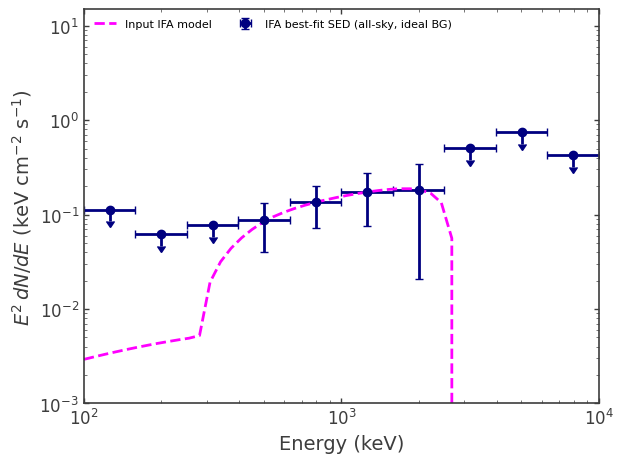

In [13]:
# Plot SED

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# ------------------------------------------------------------------
# Read simulated input spectrum
# ------------------------------------------------------------------


df = pd.read_csv(
    "Positrons_In_Flight_Annihilation_spec.dat",
    sep=r"\s+",
    skiprows=5,
    names=["dummy", "energy", "flux"],
)


# ------------------------------------------------------------------
# Read reconstructed SED
# ------------------------------------------------------------------

sed = pd.read_csv(
    "sed_true_energy.dat",
    sep=r"\s+",
)

print(sed["is_ul"])
ul = sed["is_ul"] == True
det = ~ul

# ------------------------------------------------------------------
# Plot E^2 dN/dE
# ------------------------------------------------------------------

fig, ax = plt.subplots()

# Frame on all four sides
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(1.2)

# Ticks on all four sides
ax.tick_params(
    axis="both",
    which="both",
    direction="in",
    top=True,
    right=True,
)


# ------------------------------------------------------------------
# Detected SED bins
# ------------------------------------------------------------------

E = sed.loc[det, "energy_keV"].to_numpy()
flux = sed.loc[det, "flux"].to_numpy()
flux_err = sed.loc[det, "flux_err_1sigma"].to_numpy()

xerr_low = sed.loc[det, "energy_err_low_keV"].to_numpy()
xerr_high = sed.loc[det, "energy_err_high_keV"].to_numpy()

y = E**2 * flux
yerr = E**2 * flux_err

ax.errorbar(
    E,
    y,
    xerr=[xerr_low, xerr_high],
    yerr=yerr,
    fmt="o",
    capsize=3,
    color="navy",
    label="IFA best-fit SED (all-sky, ideal BG)",
)


# ------------------------------------------------------------------
# 95% upper limits
# ------------------------------------------------------------------

E_ul = sed.loc[ul, "energy_keV"].to_numpy()
flux_ul = sed.loc[ul, "flux_ul95"].to_numpy()

xerr_low_ul = sed.loc[ul, "energy_err_low_keV"].to_numpy()
xerr_high_ul = sed.loc[ul, "energy_err_high_keV"].to_numpy()

y_ul = E_ul**2 * flux_ul

# yerr here only controls the visual length of the downward UL arrow
ax.errorbar(
    E_ul,
    y_ul,
    xerr=[xerr_low_ul, xerr_high_ul],
    yerr=0.25 * y_ul,
    uplims=True,
    fmt="o",
    capsize=3,
    color="navy",
    label="_nolabel_",
)


# ------------------------------------------------------------------
# Input model
# ------------------------------------------------------------------

ax.plot(
    df["energy"],
    df["energy"]**2 * df["flux"],
    linestyle="--",
    color="magenta",
    label="Input IFA model",
)


# ------------------------------------------------------------------
# Formatting
# ------------------------------------------------------------------

ax.set_xscale("log")
ax.set_yscale("log")

ax.set_xlabel("Energy (keV)")
ax.set_ylabel(
    r"$E^2\,dN/dE$ (keV cm$^{-2}$ s$^{-1}$)"
)

ax.set_xlim(100, 10000)
ax.set_ylim(1e-3, 15)

ax.legend(
    frameon=False,
    ncol=2,
    loc=2,
)

fig.tight_layout()

fig.savefig(
    "true_energy_sed_paper_plot_2.pdf",
)

plt.show()
plt.close(fig)